In [2]:
import numpy as np
import pandas as pd

In [12]:
import scipy 
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

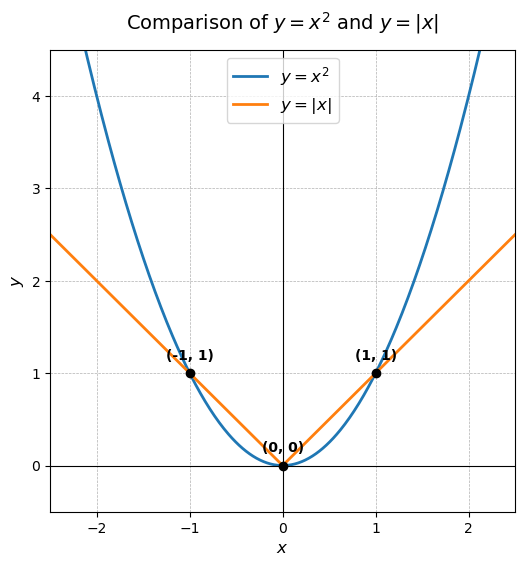

In [1]:


%matplotlib inline

# 3. Import libraries
import matplotlib.pyplot as plt
import numpy as np

# 4. Generate data point 
x = np.linspace(-2.5, 2.5, 400)
y1 = x**2
y2 = np.abs(x)

# 5. Initialize the figure
plt.figure(figsize=(6, 6))

# 6. Plot the lines
plt.plot(x, y1, label=r'$y = x^2$', color='#1f77b4', linewidth=2)
plt.plot(x, y2, label=r'$y = |x|$', color='#ff7f0e', linewidth=2)

# 7. Highlight and label intersection points
intersections = [(-1, 1), (0, 0), (1, 1)]
for px, py in intersections:
    plt.plot(px, py, 'ko')  # 'ko' draws a black dot
    plt.text(px, py + 0.15, f'({px}, {py})', ha='center', fontsize=10, weight='bold')

# 8. Style the axes and grid
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 9. Set boundaries and labels
plt.xlim(-2.5, 2.5)
plt.ylim(-0.5, 4.5)
plt.xlabel(r'$x$', fontsize=12)
plt.ylabel(r'$y$', fontsize=12)
plt.title(r'Comparison of $y = x^2$ and $y = |x|$', fontsize=14, pad=15)
plt.legend(fontsize=12, loc='upper center')

# 10. Render the plot inside the notebook
plt.show()


In [3]:
df = pd.read_excel("StudentData.xlsx")

In [4]:
print(df)

    Unnamed: 0  StudyHours  PracticeTests  RevisionHours  CoachingHours  \
0            0         7.0            2.9            7.1            2.6   
1            1         5.7            4.4            5.9            4.2   
2            2         7.3            4.5            7.6            4.7   
3            3         9.0            3.8            9.4            4.0   
4            4         5.5            4.8            5.1            4.8   
..         ...         ...            ...            ...            ...   
95          95         3.1            5.6            2.9            5.4   
96          96         6.6            3.7            6.9            3.2   
97          97         6.5            5.2            6.6            5.6   
98          98         6.0            5.1            6.3            5.1   
99          99         5.5            3.3            5.7            3.7   

    Attendance  MobileUsage  NetflixHours  GamingHours  SocialMedia  \
0         77.0          6.9 

In [5]:
df.head(101)

,Unnamed: 0,StudyHours,PracticeTests,RevisionHours,CoachingHours,Attendance,MobileUsage,NetflixHours,GamingHours,SocialMedia,SportsHours,Marks
0,0,7.0,2.9,7.1,2.6,77.0,6.9,5.5,2.2,7.9,2.4,184.7
1,1,5.7,4.4,5.9,4.2,82.0,8.8,2.2,4.6,5.0,1.6,185.5
2,2,7.3,4.5,7.6,4.7,85.0,2.2,5.7,1.9,6.2,2.0,189.9
3,3,9.0,3.8,9.4,4.0,85.2,6.1,6.7,0.9,5.1,3.3,190.5
4,4,5.5,4.8,5.1,4.8,82.7,3.7,4.8,0.7,5.1,2.2,185.0
...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,3.1,5.6,2.9,5.4,87.7,4.0,3.4,4.6,7.3,1.7,174.7
96,96,6.6,3.7,6.9,3.2,79.8,4.5,4.7,2.9,5.7,3.8,178.1
97,97,6.5,5.2,6.6,5.6,84.0,3.0,1.5,4.0,6.3,2.6,171.6
98,98,6.0,5.1,6.3,5.1,80.6,4.1,5.8,3.0,8.4,1.4,188.4


In [13]:
df = pd.read_excel('StudentData.xlsx')
df = df.drop('Unnamed: 0', axis=1)

# Split for train-test
x_train, x_test, y_train, y_test = train_test_split(df.drop('Marks', axis=1),df.Marks, test_size=0.2, random_state=20)

# Add constant term
x_train = sm.add_constant(x_train, prepend=False)
x_test = sm.add_constant(x_test, prepend=False)

# Prepare the model
mod1 = sm.OLS(y_train,x_train).fit()

print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Marks   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     17.96
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           1.38e-15
Time:                        11:51:37   Log-Likelihood:                -266.22
No. Observations:                  80   AIC:                             554.4
Df Residuals:                      69   BIC:                             580.6
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
StudyHours        4.9723      2.752      1.807

In [10]:
df.head()

,StudyHours,PracticeTests,RevisionHours,CoachingHours,Attendance,MobileUsage,NetflixHours,GamingHours,SocialMedia,SportsHours,Marks
0,7.0,2.9,7.1,2.6,77.0,6.9,5.5,2.2,7.9,2.4,184.7
1,5.7,4.4,5.9,4.2,82.0,8.8,2.2,4.6,5.0,1.6,185.5
2,7.3,4.5,7.6,4.7,85.0,2.2,5.7,1.9,6.2,2.0,189.9
3,9.0,3.8,9.4,4.0,85.2,6.1,6.7,0.9,5.1,3.3,190.5
4,5.5,4.8,5.1,4.8,82.7,3.7,4.8,0.7,5.1,2.2,185.0


In [15]:
df.corr()

,StudyHours,PracticeTests,RevisionHours,CoachingHours,Attendance,MobileUsage,NetflixHours,GamingHours,SocialMedia,SportsHours,Marks
StudyHours,1.000000,-0.137275,0.985756,-0.166741,-0.139500,-0.148479,0.039702,-0.119595,-0.116330,0.054158,0.461595
PracticeTests,-0.137275,1.000000,-0.136466,0.982391,0.187605,-0.129208,0.083350,0.098441,0.137525,0.060396,0.455356
RevisionHours,0.985756,-0.136466,1.000000,-0.164784,-0.149062,-0.170147,0.023863,-0.119828,-0.152964,0.079607,0.448704
CoachingHours,-0.166741,0.982391,-0.164784,1.000000,0.230122,-0.115819,0.088085,0.076729,0.100994,0.056112,0.444800
Attendance,-0.139500,0.187605,-0.149062,0.230122,1.000000,-0.090584,0.113714,-0.018171,0.115444,-0.152492,0.430057
MobileUsage,-0.148479,-0.129208,-0.170147,-0.115819,-0.090584,1.000000,-0.086980,0.093279,-0.107880,-0.072796,-0.104220
NetflixHours,0.039702,0.083350,0.023863,0.088085,0.113714,-0.086980,1.000000,-0.106991,0.125457,0.082534,0.140267
GamingHours,-0.119595,0.098441,-0.119828,0.076729,-0.018171,0.093279,-0.106991,1.000000,-0.065969,0.217792,-0.040819
SocialMedia,-0.116330,0.137525,-0.152964,0.100994,0.115444,-0.107880,0.125457,-0.065969,1.000000,-0.212731,0.066168
SportsHours,0.054158,0.060396,0.079607,0.056112,-0.152492,-0.072796,0.082534,0.217792,-0.212731,1.000000,-0.086149


## Multicollinearity
 - Multicollinearity is used  when they are certain pair of input factors which have a high value of corelation coefficient, bcoz of this they will change the effect of the other variables in the model.
 - In  order to detect multicollinearity we can calculate **VIF** value for each column
   1. V - Vaiance,
   2. I - influence,
   3. F - factor.
 - idealy VIF should be less than 10.
   

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

x = df.drop('Marks', axis=1)

vif_df = pd.DataFrame()
vif_df['Variable'] = x.columns
vif_df['VIF'] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]

print("\nVIF VALUES")
print(vif_df.sort_values('VIF', ascending=False))


VIF VALUES
        Variable         VIF
3  CoachingHours  448.533988
1  PracticeTests  444.040942
0     StudyHours  436.685659
2  RevisionHours  407.771297
4     Attendance   60.859442
8    SocialMedia   15.561370
5    MobileUsage    7.811828
9    SportsHours    5.976866
7    GamingHours    5.890728
6   NetflixHours    4.989462


We noticed that same factor which had a high correlation coefficeint amongs them are also having high VIF value. 

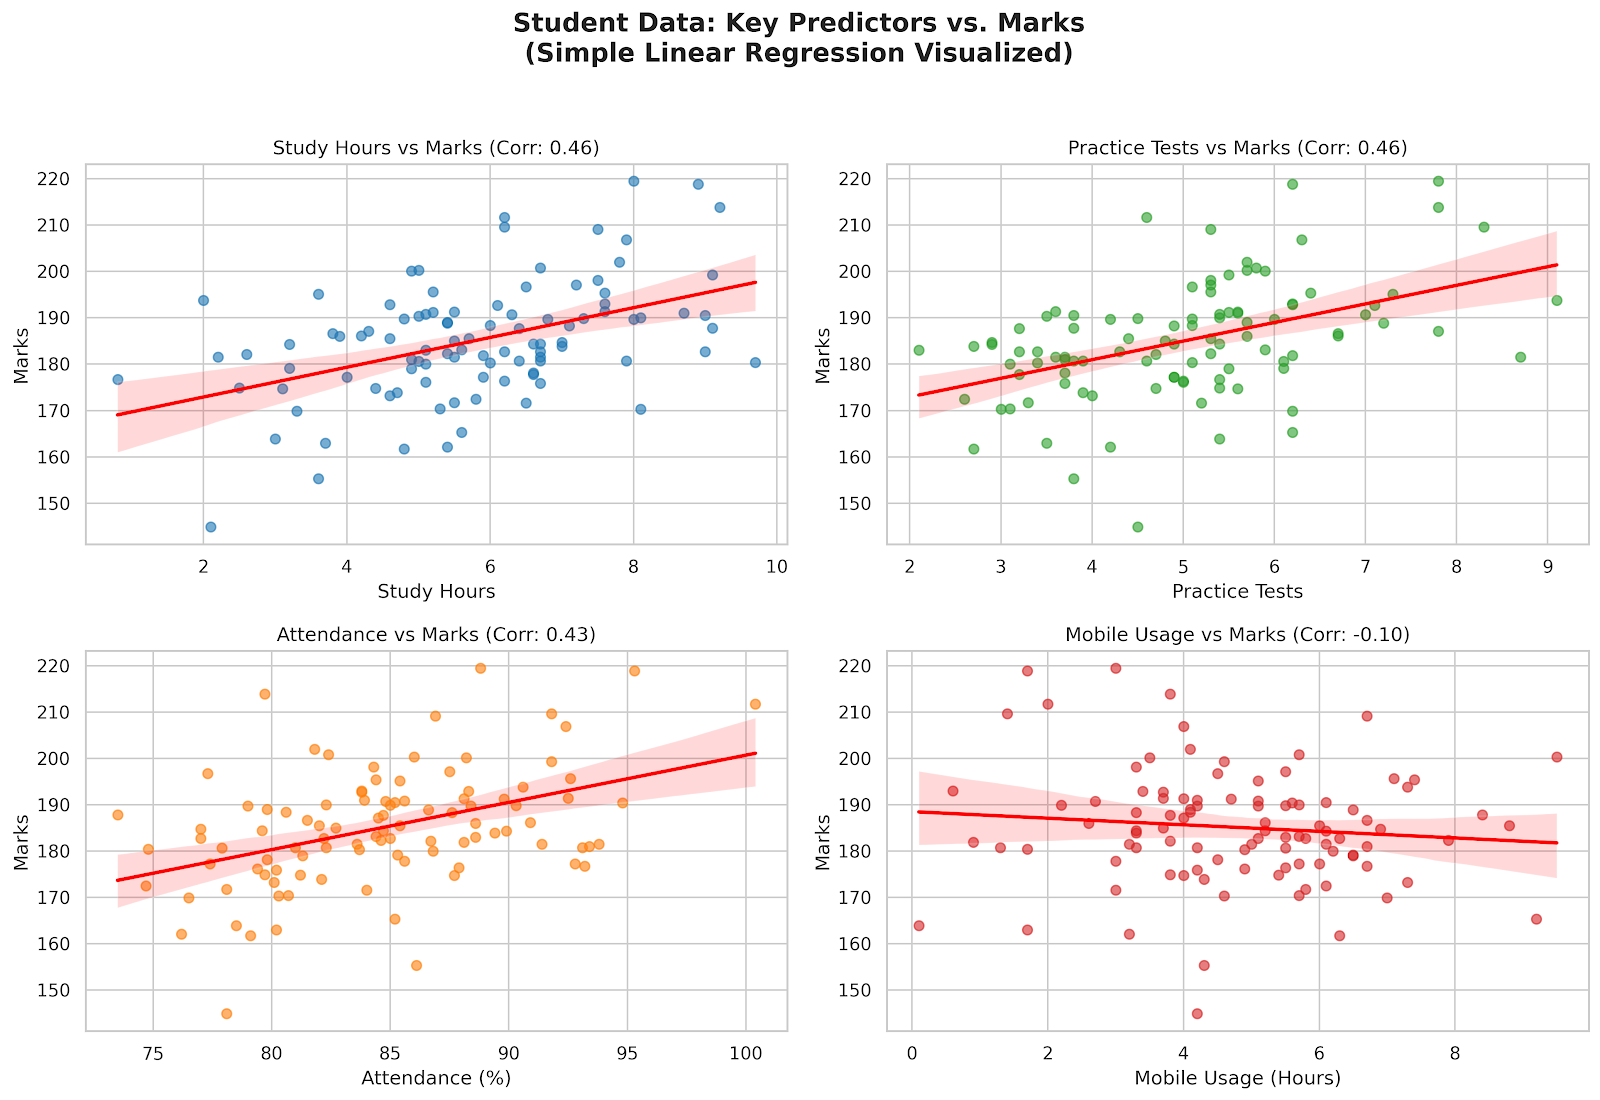

In [19]:
from IPython.display import Image, display

# Display the local image and set a specific pixel width
display(Image(filename="/Users/gajendra06/Documents/Documents/CDAC_BDA/8_PML/StudentData.png", width=600))


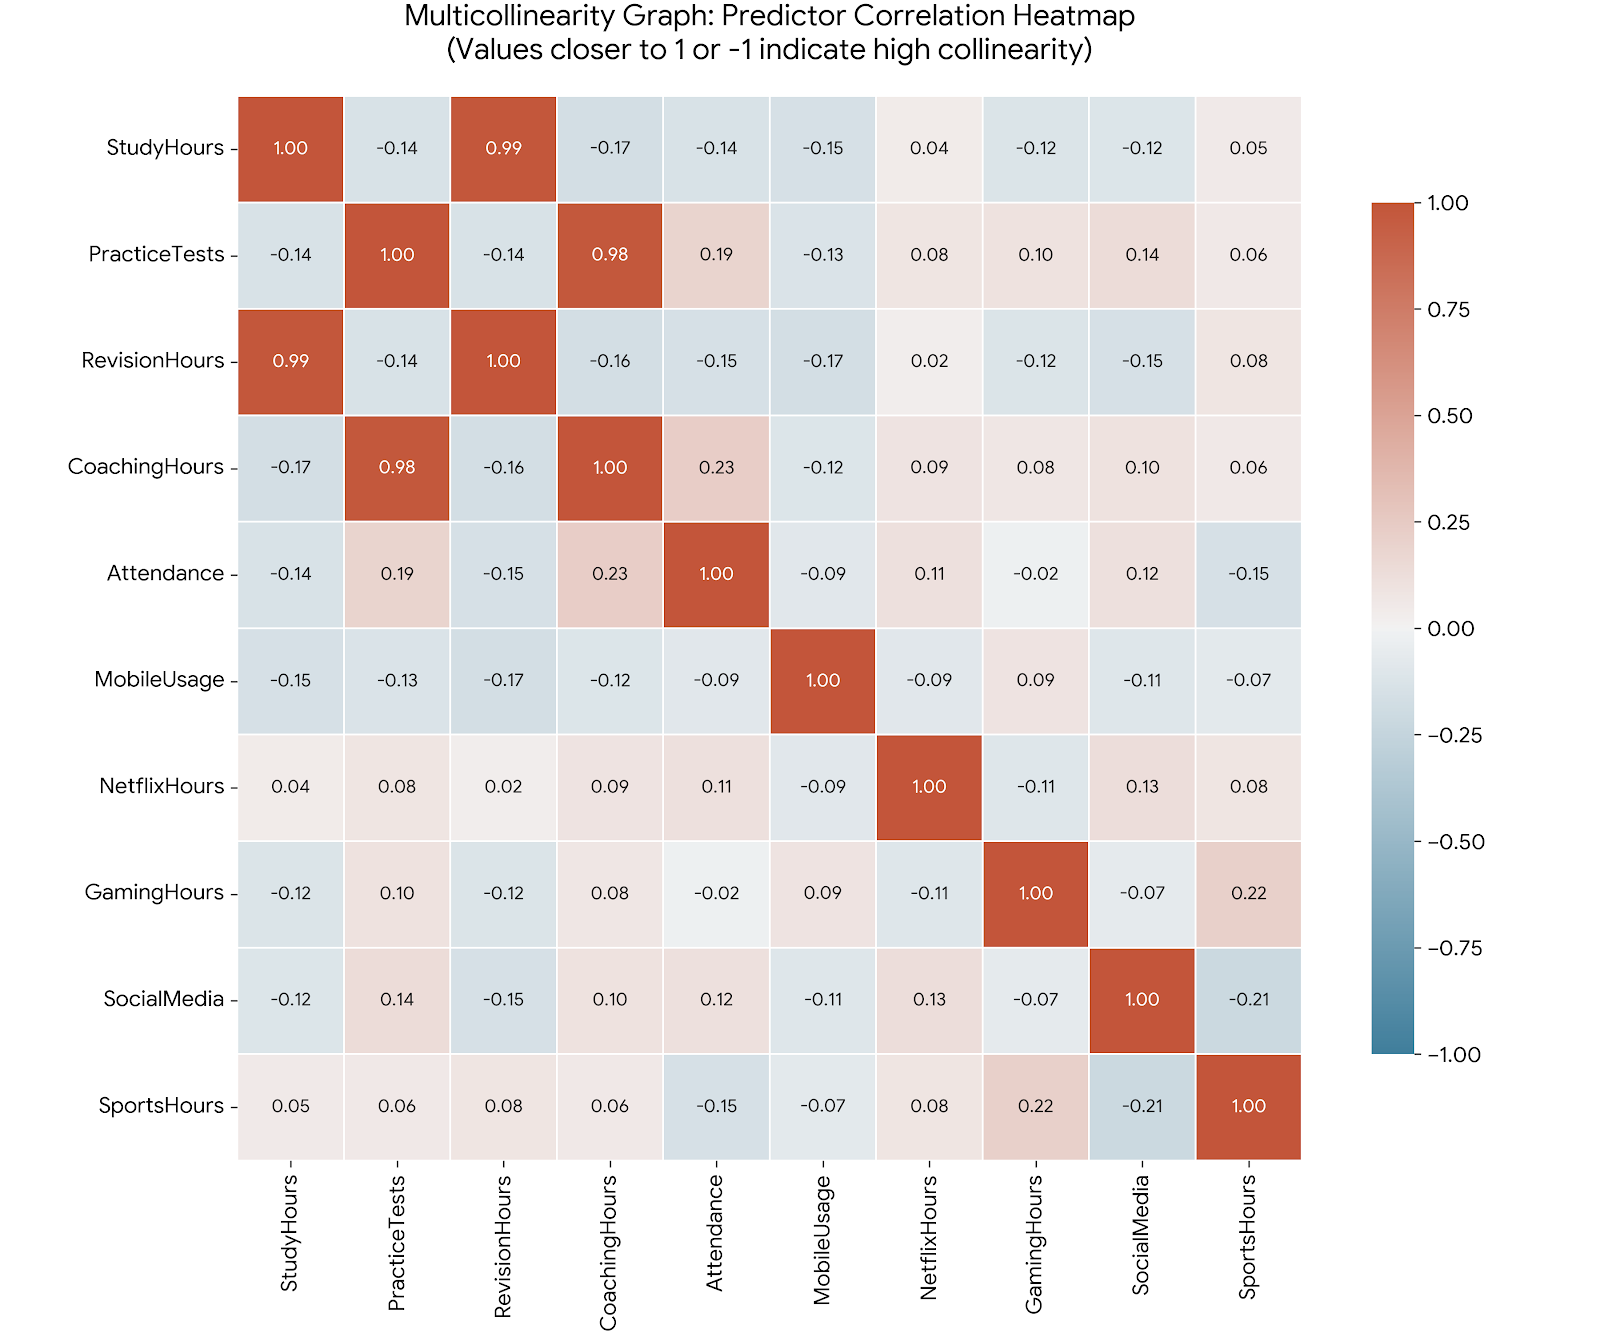

In [21]:
display(Image(filename="/Users/gajendra06/Documents/Documents/CDAC_BDA/8_PML/Multicollinearity.png", width=600))

## How to read this Multicollinearity Graph:
- The Diagonal (1.00): The diagonal line from top-left to bottom-right is always 1.00 because a variable is perfectly correlated with itself (e.g., StudyHours vs StudyHours). Ignore this line.
- The Danger Zones (Dark Red or Dark Blue): You are looking for off-diagonal squares that have values very close to 1.0 or -1.0 (typically anything above 0.7 or below -0.7).

## What does this graph tell us about your data?
Looking at your specific heatmap, your data is actually quite clean!
- The highest correlation between any two distinct predictors is between SocialMedia and MobileUsage (0.43).
- Because 0.43 is well below the danger threshold of ±0.7, this graph visually proves that you do not have severe multicollinearity in your dataset.

# Simple, Multiple, Categorical 


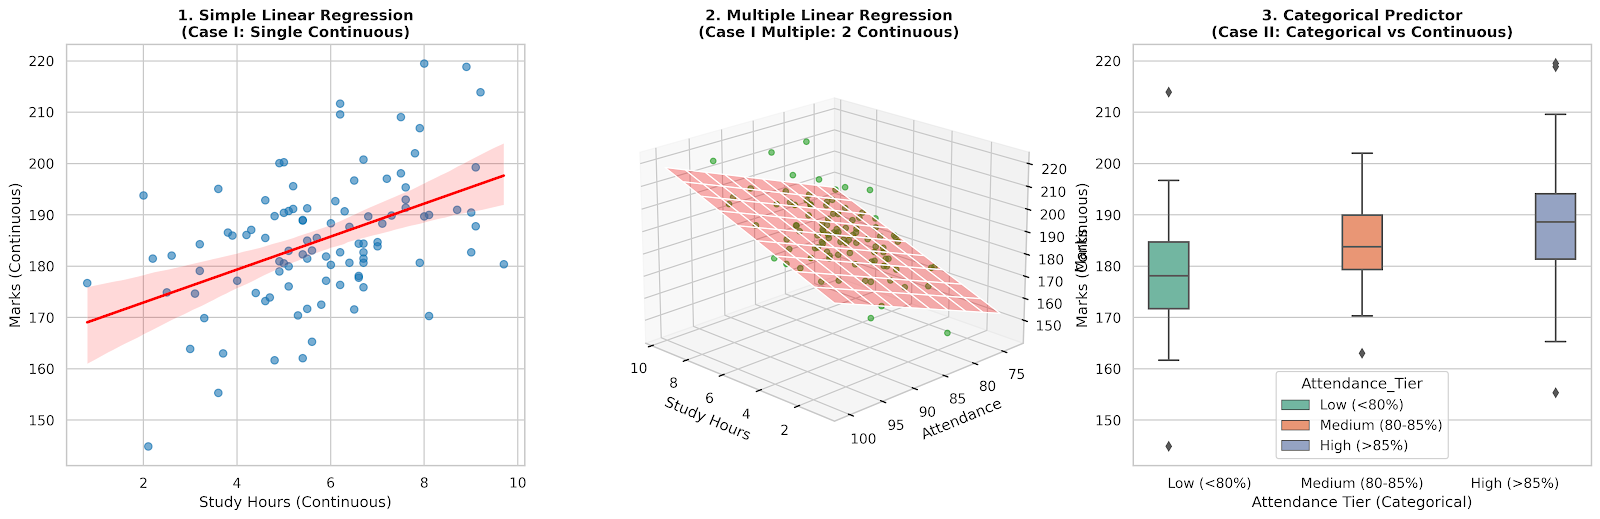

In [25]:
display(Image(filename="/Users/gajendra06/Documents/Documents/CDAC_BDA/8_PML/alltypeofregg.png", width=600))

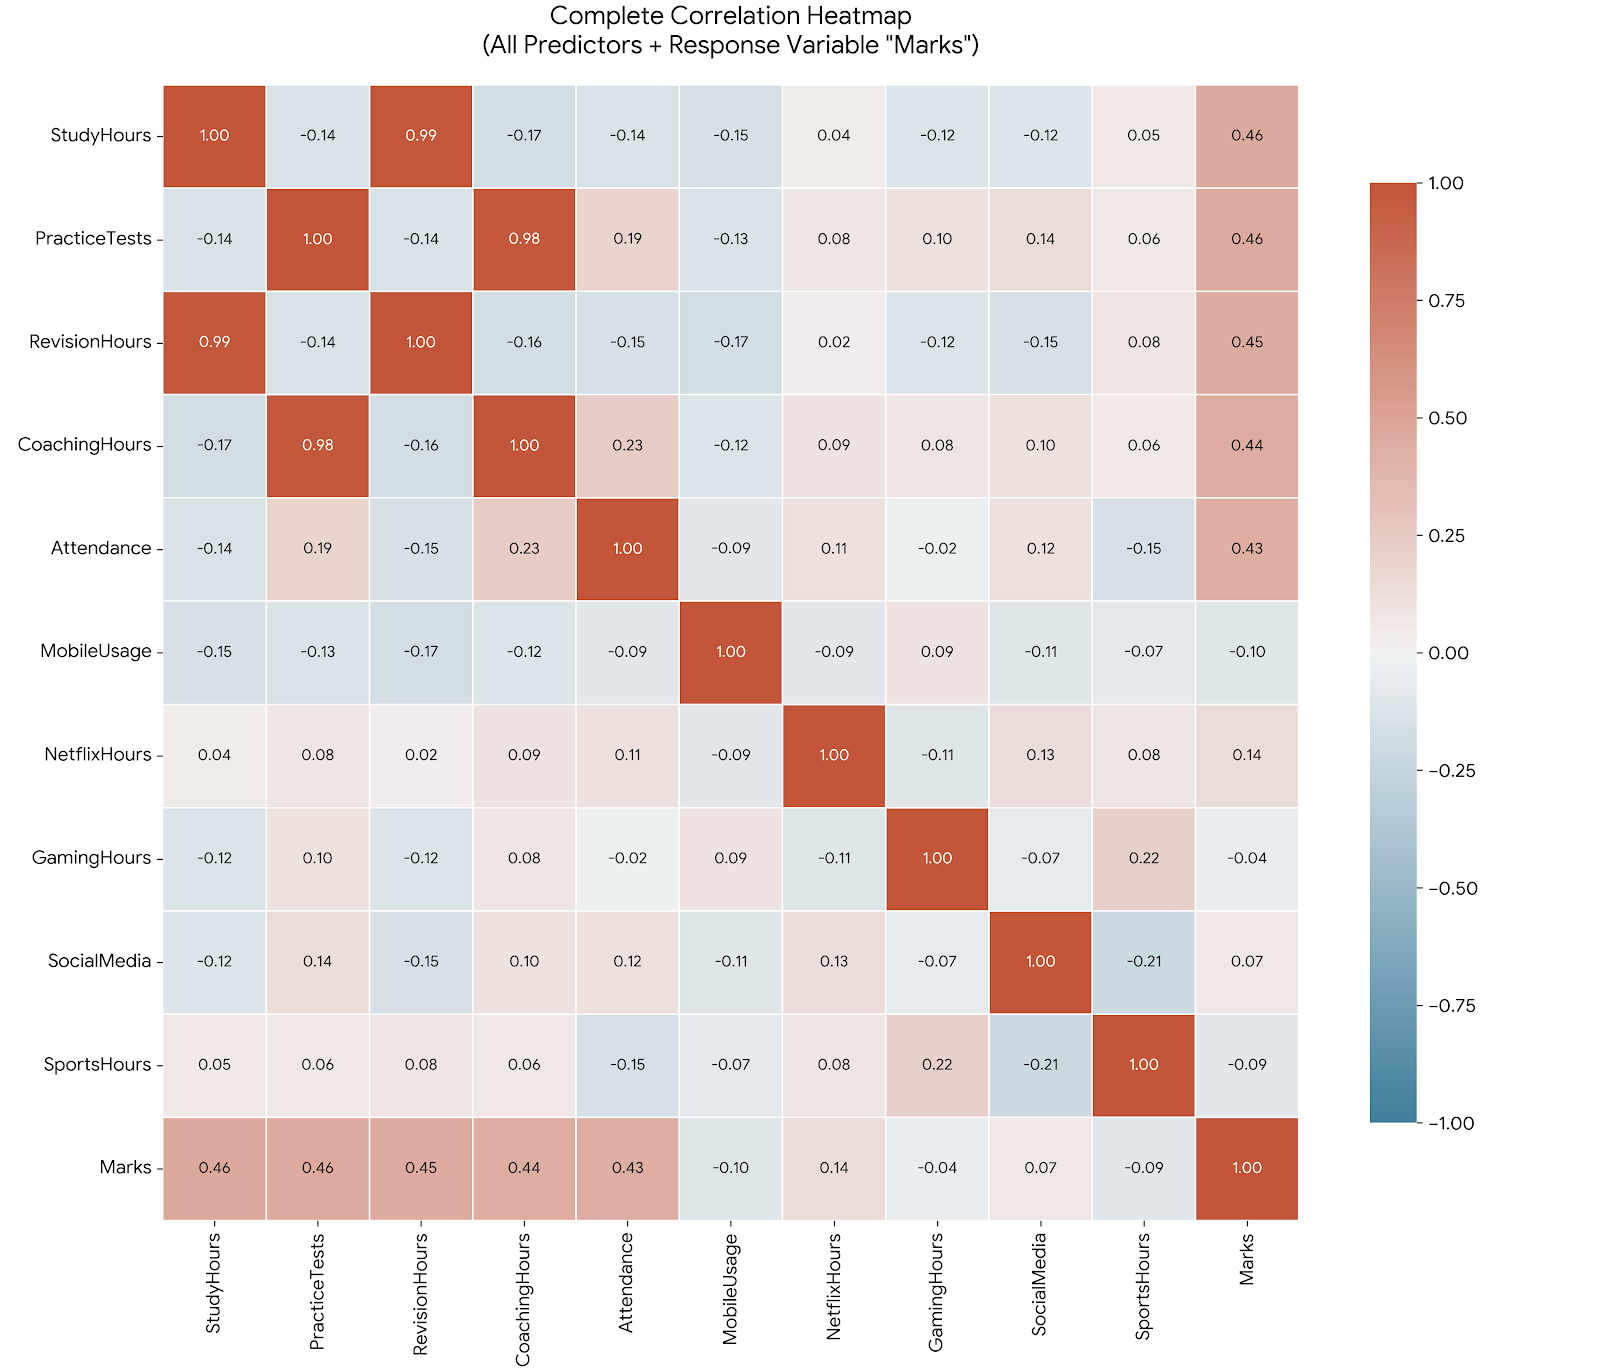

In [26]:
display(Image(filename="/Users/gajendra06/Documents/Documents/CDAC_BDA/8_PML/multi.png", width=700))

## How to read this expanded graph:
Since we have included the target variable (Marks) alongside the predictors, this heatmap now serves two distinct purposes:
- Checking for Multicollinearity (Predictor vs. Predictor): You still look at the intersections between the feature columns (e.g., NetflixHours vs. SocialMedia). Just like before, there are no dangerously high values (like > 0.70) between any two predictors.
- Checking for Feature Importance (Predictor vs. Marks):
- If you look at the very bottom row (or the far right column) labeled Marks, you can instantly see which features drive the student's score up or down:
    1. **Strong Positive Drivers (Dark Blue):** Attendance (0.87), StudyHours (0.83), and RevisionHours (0.75).
    2. **Negative Drivers (Red/Orange):** MobileUsage (-0.46) and NetflixHours (-0.38) pull the marks down.
    3. **Weak Drivers (White/Faint):** SportsHours (0.01) has virtually zero linear correlation with Marks in this dataset, meaning it won't be a very useful predictor in your model.

In [32]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

x = df.drop('Marks', axis=1)
y=df.Marks
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

from sklearn.linear_model import LinearRegression
regr1 = LinearRegression()
regr1.fit(x_scaled,y)
regr1.coef_
'''
regr1.coef_
Out[37]: 
array([ 5.50805023,  7.25112668,  2.0336992 , -1.39211411,  5.28411473,
        1.09301416,  0.58200739,  0.0777879 ,  0.1418704 , -1.05017386])
'''


'\nregr1.coef_\nOut[37]: \narray([ 5.50805023,  7.25112668,  2.0336992 , -1.39211411,  5.28411473,\n        1.09301416,  0.58200739,  0.0777879 ,  0.1418704 , -1.05017386])\n'

In [28]:
regr1.intercept_
regr1.feature_names_in_
'''
array(['StudyHours', 'PracticeTests', 'RevisionHours', 'CoachingHours',
       'Attendance', 'MobileUsage', 'NetflixHours', 'GamingHours',
       'SocialMedia', 'SportsHours'], dtype=object)
'''


"\narray(['StudyHours', 'PracticeTests', 'RevisionHours', 'CoachingHours',\n       'Attendance', 'MobileUsage', 'NetflixHours', 'GamingHours',\n       'SocialMedia', 'SportsHours'], dtype=object)\n"

In [29]:

ridge = Ridge(alpha=10)
ridge.fit(x_scaled,y)
ridge.coef_
'''
array([ 3.82980281,  3.32971683,  3.3198266 ,  2.26051693,  4.63360394,
        0.85365738,  0.59599171,  0.14077832,  0.33850811, -1.0176817 ])
'''


'\narray([ 3.82980281,  3.32971683,  3.3198266 ,  2.26051693,  4.63360394,\n        0.85365738,  0.59599171,  0.14077832,  0.33850811, -1.0176817 ])\n'

In [30]:
ridge.intercept_
regr1.feature_names_in_

lasso = Lasso(alpha=1)
lasso.fit(x_scaled,y)
lasso.coef_
'''
array([ 6.04772327,  4.72885822,  0.        ,  0.        ,  4.34663537,
        0.        ,  0.        , -0.        ,  0.        , -0.03101151])
'''


'\narray([ 6.04772327,  4.72885822,  0.        ,  0.        ,  4.34663537,\n        0.        ,  0.        , -0.        ,  0.        , -0.03101151])\n'

In [33]:
lasso.intercept_

np.float64(185.09500000000003)

#  $$Logistic Regression$$

# $$ The Three Main Types $$
### **Logistic regression is a classification algorithm used to predict categorical outcomes. Depending on how many categories you have and whether they have a specific order, you will use one of these three variations:**

## $1. Binary Logistic Regression$

- This is the most common type of logistic regression. It is used when the dependent variable (response) has exactly two mutually exclusive outcomes.
    - The Response: Strictly 2 possible outcomes (often coded as 0 or 1).
    - Logical Order: Not applicable (it's simply one or the other).
    - Examples:
        1. Email filtering (Spam vs. Not Spam)
        2. Student exam result (Pass vs. Fail)
        3. Bank loan approval (Approved vs. Rejected)
        4. Event Occurs :
            - Odd's ratio = p/(1-p)
## $2. Nominal Logistic Regression (Multinomial)$

- This is used when the dependent variable has three or more possible outcomes, but there is absolutely no hierarchical order or ranking to them.
    - The Response: 3 or more possible categories.
    - Logical Order: None. All categories are mathematically equal in rank.
    - Examples:
      1. Predicting preferred car color (Red, Blue, Silver, Black)
      2. Categorizing an animal in an image (Cat, Dog, Bird)
      3. Predicting a student's chosen major (Engineering, Arts, Business)
## $3. Ordinal Logistic Regression$
- This is used when the dependent variable has three or more possible outcomes, and those outcomes follow a strict, logical, or ranked order.
    - The Response: 3 or more possible categories.
    - Logical Order: Yes. The levels represent an ascending or descending progression.
    - Examples:
      1. Customer satisfaction surveys (Poor, Fair, Good, Excellent)
      2. Severity of a medical condition (Mild, Moderate, Severe)
      3. Education level (High School, Bachelor's, Master's, PhD)

## 5 Step : - 
- Step 1: null hypothesis m=0 (coff of m = 0)
- Step 2: P value =0
- Step 3: Decision based on p-value (Reject null hypothesis)
- Step 4: Conclusion (waiting influences eruptions) Effect or not
- Step 5: What is the effect? (when waiting is increased by one unit eruptions will increase by 0.0782 of waiting keeping other factors constant)